In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use('ggplot')


In [5]:
df = pd.read_csv("Titanic-Dataset.csv")

print("First 5 Rows:")
display(df.head())

print("\nShape:", df.shape)

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe(include="all"))

First 5 Rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Shape: (891, 12)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabi

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [6]:
# Fill missing values
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Drop Cabin column
df.drop("Cabin", axis=1, inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("Remaining Missing Values:")
print(df.isnull().sum())

print("\nDataset Shape:", df.shape)

Remaining Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Dataset Shape: (891, 11)


C:\Users\Divyansh\AppData\Local\Temp\ipykernel_23368\3343432353.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\Divyansh\AppData\Local\Temp\ipykernel_23368\3343432353.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


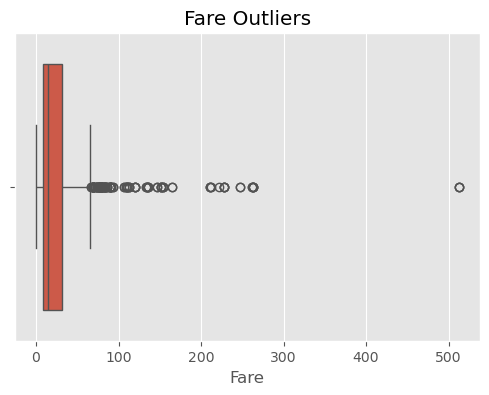

Shape after removing outliers: (775, 11)


In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Fare"])
plt.title("Fare Outliers")
plt.show()

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Fare"] >= lower) & (df["Fare"] <= upper)]

print("Shape after removing outliers:", df.shape)

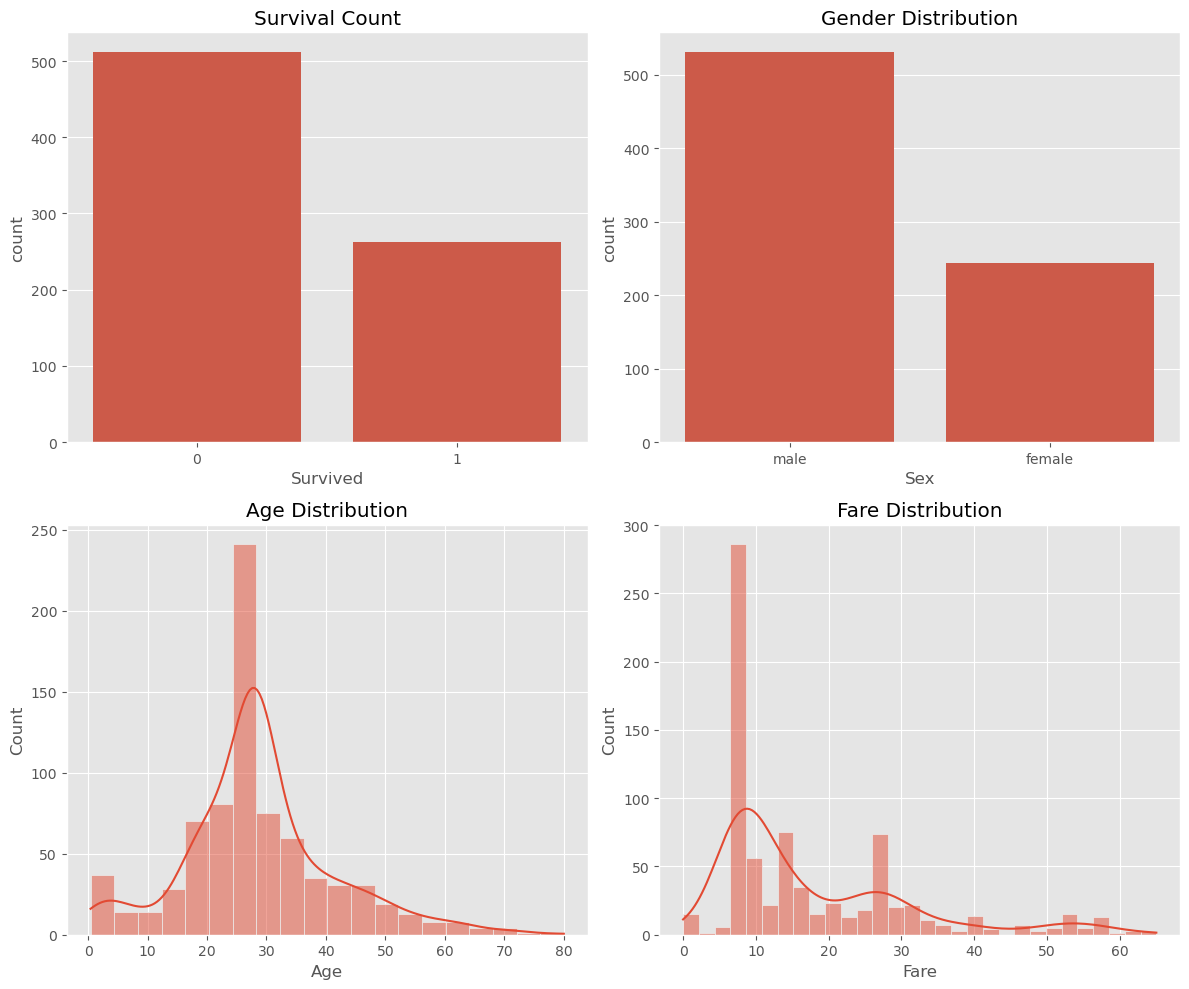

In [8]:
fig, axes = plt.subplots(2,2, figsize=(12,10))

sns.countplot(data=df, x="Survived", ax=axes[0,0])
axes[0,0].set_title("Survival Count")

sns.countplot(data=df, x="Sex", ax=axes[0,1])
axes[0,1].set_title("Gender Distribution")

sns.histplot(df["Age"], bins=20, kde=True, ax=axes[1,0])
axes[1,0].set_title("Age Distribution")

sns.histplot(df["Fare"], bins=30, kde=True, ax=axes[1,1])
axes[1,1].set_title("Fare Distribution")

plt.tight_layout()
plt.show()

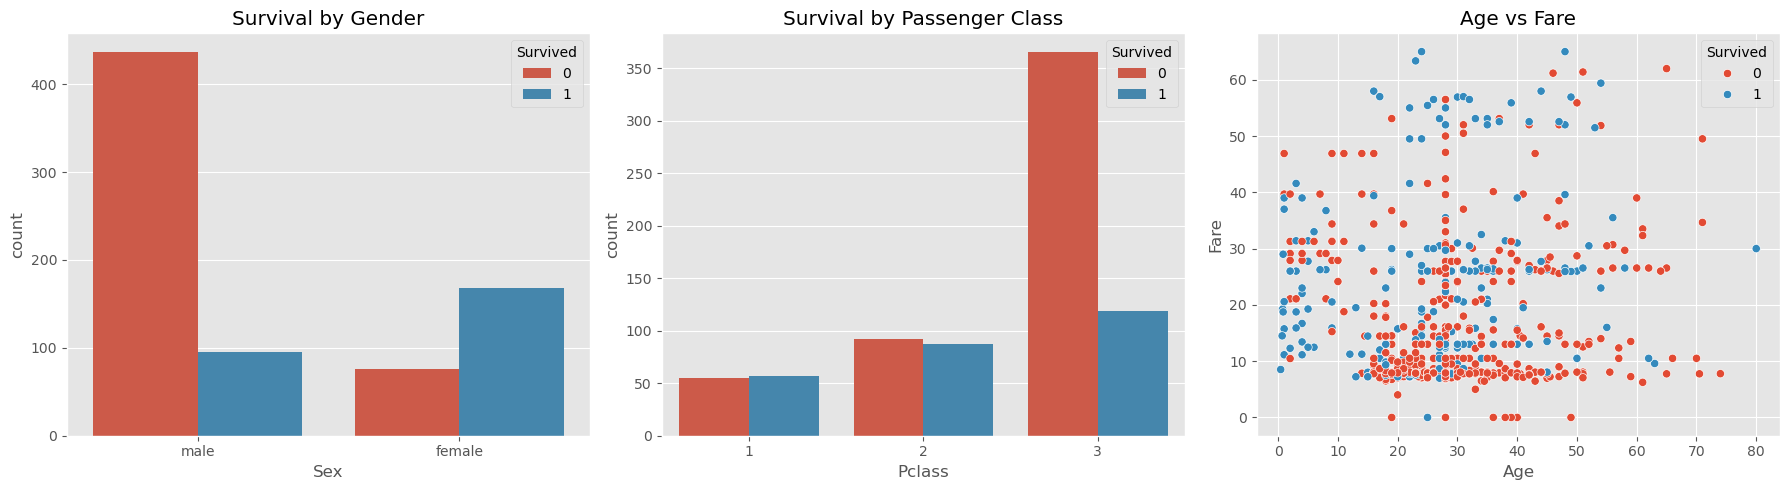

In [9]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.countplot(data=df, x="Sex", hue="Survived", ax=axes[0])
axes[0].set_title("Survival by Gender")

sns.countplot(data=df, x="Pclass", hue="Survived", ax=axes[1])
axes[1].set_title("Survival by Passenger Class")

sns.scatterplot(data=df, x="Age", y="Fare", hue="Survived", ax=axes[2])
axes[2].set_title("Age vs Fare")

plt.tight_layout()
plt.show()

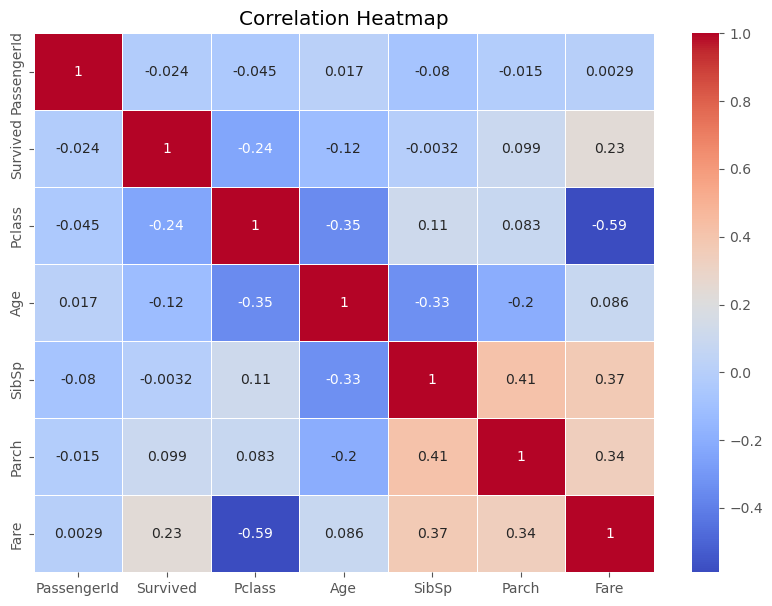

In [10]:
plt.figure(figsize=(10,7))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [11]:
df.to_csv("Cleaned_Titanic.csv", index=False)

print("="*40)
print("PROJECT COMPLETED")
print("="*40)
print("Final Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Cleaned dataset saved as 'Cleaned_Titanic.csv'")

PROJECT COMPLETED
Final Shape: (775, 11)
Missing Values: 0
Duplicate Rows: 0
Cleaned dataset saved as 'Cleaned_Titanic.csv'
